In [54]:
import os
import pandas as pd

from rdkit import Chem
from rdkit.Chem import AllChem
from mapchiral import mapchiral

import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = "Menlo"
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams.update({'font.size': 22})

#### Plot the diversity of selected actives

Check diversity within selected actives for each target: ECFP4

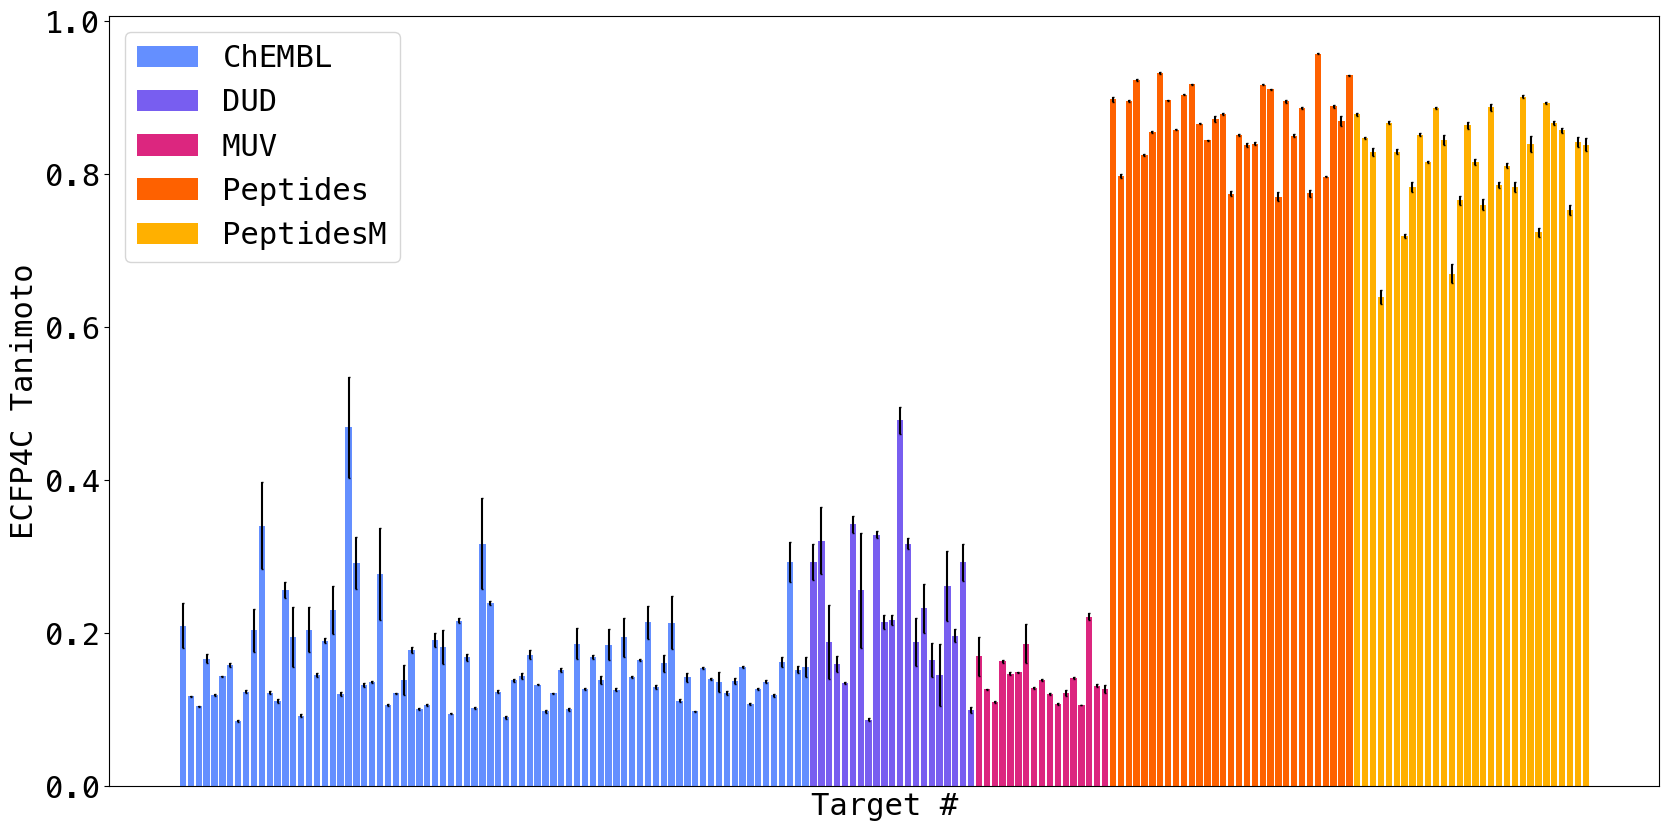

In [71]:
actives_ecfp = pd.DataFrame()
directories = ['ChEMBL', 'DUD', 'MUV', 'Peptides', 'PeptidesM']
colors = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000']

for idx, directory in enumerate(directories):
    for filename in os.listdir(f'../queries/{directory}/'):
        active_smiles = pd.read_csv(f'../queries/{directory}/{filename}')['smiles'].values.tolist()
        fingerprints = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(smiles), 2, nBits=2048, useChirality=True) for smiles in active_smiles]
        similarities = []
        for i in range(len(fingerprints)):
            for j in range(i+1, len(fingerprints)):
                similarities.append(AllChem.DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j]))
        target_name = filename.split('_')[0] + '_' + filename.split('_')[1]
        average_similarity = sum(similarities) / len(similarities)
        standard_deviation = sum([(x - average_similarity)**2 for x in similarities]) / len(similarities)
        actives_ecfp = actives_ecfp.append({'target': target_name, 'average_tanimoto': average_similarity, 'standard_deviation': standard_deviation, 'color': colors[idx]}, ignore_index=True)

# Plot
fig, ax = plt.subplots(figsize=(20, 10))
ax.bar(actives_ecfp['target'], actives_ecfp['average_tanimoto'], yerr=actives_ecfp['standard_deviation'], capsize=1, color=actives_ecfp['color'])

for idx, directory in enumerate(directories):
    ax.bar(0, 0, color=colors[idx], label=directory)

ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.set_ylabel('ECFP4C Tanimoto')
ax.set_xlabel('Target #')
ax.legend()    

plt.savefig('plots/ecfp4c_query_similarity.png', bbox_inches='tight', dpi=1200)

Check diversity within selected actives for each target: MAP4C

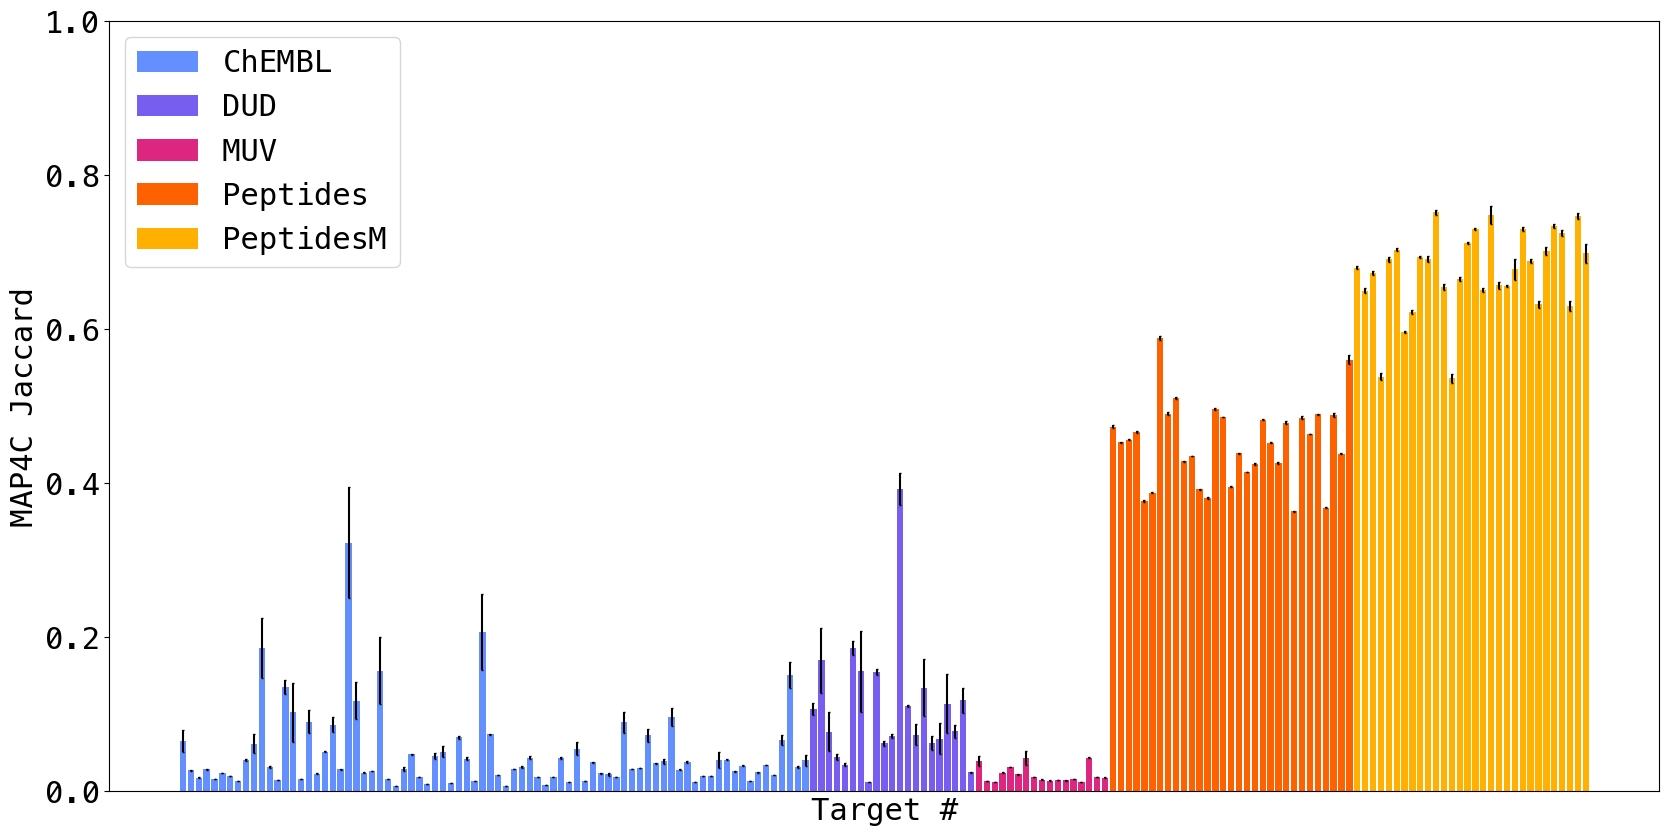

In [70]:
actives_map4 = pd.DataFrame()
directories = ['ChEMBL', 'DUD', 'MUV', 'Peptides', 'PeptidesM']
colors = ['#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000']

for idx, directory in enumerate(directories):
    for filename in os.listdir(f'../queries/{directory}/'):
        active_smiles = pd.read_csv(f'../queries/{directory}/{filename}')['smiles'].values.tolist()
        fingerprints = [mapchiral.encode(Chem.MolFromSmiles(smiles), max_radius=2, n_permutations=2048) for smiles in active_smiles]
        similarities = []
        for i in range(len(fingerprints)):
            for j in range(i+1, len(fingerprints)):
                similarities.append(mapchiral.jaccard_similarity(fingerprints[i], fingerprints[j]))
        target_name = filename.split('_')[0] + '_' + filename.split('_')[1]
        average_similarity = sum(similarities) / len(similarities)
        standard_deviation = sum([(x - average_similarity)**2 for x in similarities]) / len(similarities)
        actives_map4 = actives_map4.append({'target': target_name, 'average_jaccard': average_similarity, 'standard_deviation': standard_deviation, 'color': colors[idx]}, ignore_index=True)

# Plot
fig, ax = plt.subplots(figsize=(20, 10))
ax.bar(actives_map4['target'], actives_map4['average_jaccard'], yerr=actives_map4['standard_deviation'], capsize=1, color=actives_map4['color'])

for idx, directory in enumerate(directories):
    ax.bar(0, 0, color=colors[idx], label=directory)

ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
ax.set_ylabel('MAP4C Jaccard')
ax.set_xlabel('Target #')
ax.set_ylim(0, 1)
ax.legend()    

plt.savefig('plots/map4c_query_similarity.png', bbox_inches='tight', dpi=1200)